In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [2]:
import scanpy as sc
import scanpy.external as sce
import pandas as pd

read the NE_cluster_stages.csv first

In [3]:
NE_cluster_stages = pd.read_csv("NE_cluster_stages.csv", index_col=0, keep_default_na=False)  # preserve NA strings, not read it as NaN
NE_cluster_stages

,discrete_cancer_stage
leiden,
0,IV
1,IV
2,I
3,IV
4,I
5,IV
6,I
7,I
8,I


In [4]:
NE_cluster_stages.index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55],
      dtype='int64', name='leiden')

In [5]:
type(NE_cluster_stages)

pandas.core.frame.DataFrame

In [6]:
type(NE_cluster_stages.loc[0])

pandas.core.series.Series

In [7]:
type(NE_cluster_stages.loc[0].iloc[0])

str

In [8]:
NE_cluster_stages.loc[0].iloc[0]

'IV'

In [5]:
adata = sc.read_h5ad("NE_reclustered.h5ad")
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [7]:
adata.obs["leiden_scVI"].iloc[0]

'2'

In [8]:
discrete_cancer_stage_annotation_list = []
for i in range(len(adata.obs_names)):
    discrete_cancer_stage_annotation_list.append(NE_cluster_stages.loc[int(adata.obs["leiden_scVI"].iloc[i])].iloc[0])

print(discrete_cancer_stage_annotation_list[:20])

['I', 'I', 'I', 'I', 'I', 'IV', 'I', 'I', 'I', 'IV', 'IV', 'IV', 'I', 'I', 'IV', 'IV', 'I', 'IV', 'IV', 'I']


In [9]:
adata.obs["discrete_cancer_stage"] = discrete_cancer_stage_annotation_list

In [13]:
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [14]:
# counts
adata.X

array([[ 0. ,  0. ,  0. , ...,  0. ,  0. ,  7. ],
       [ 0. ,  0. ,  0. , ...,  0. ,  0. ,  3.5],
       [ 0. ,  0. ,  1. , ...,  0. ,  0. ,  4. ],
       ...,
       [ 0. ,  0. ,  0. , ...,  0. ,  0. ,  0.5],
       [ 0. ,  4. ,  0. , ...,  0. ,  0. , 11. ],
       [ 0. ,  0. ,  0. , ...,  0. ,  0. , 16. ]])

In [10]:
# normalized counts
adata.layers["scvi_normalized"]

array([[ 1.3660967 ,  1.5102433 ,  0.84264374, ...,  0.13126898,
         0.14069788, 64.436554  ],
       [ 1.0688094 ,  1.1575099 ,  0.64938474, ...,  0.10362872,
         0.1495432 , 75.53627   ],
       [ 1.3362994 ,  1.576865  ,  0.7316775 , ...,  0.13519967,
         0.1357406 , 71.79623   ],
       ...,
       [ 1.542854  ,  4.503489  ,  0.64815706, ...,  0.13795677,
         0.2050788 , 48.485855  ],
       [ 0.85531384,  7.3508344 ,  0.5020641 , ...,  0.1165168 ,
         0.18252064, 60.115337  ],
       [ 0.98095864,  4.400981  ,  0.55424696, ...,  0.10603125,
         0.2386962 , 87.08725   ]], dtype=float32)

transformation workflow

visualization

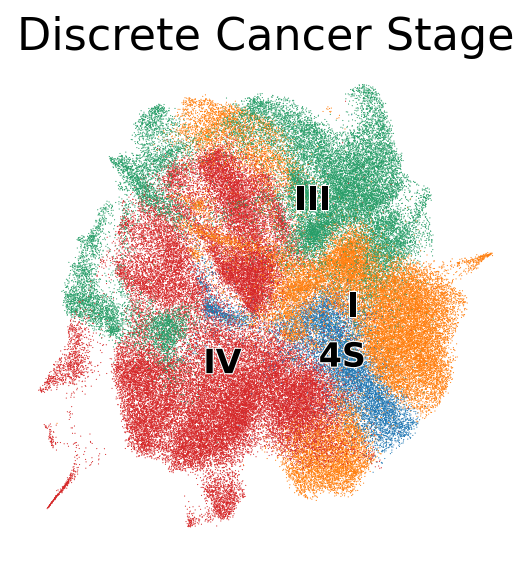

In [11]:
sc.set_figure_params(fontsize=20)
sc.pl.umap(adata, color='discrete_cancer_stage', legend_loc='on data',
           frameon=False, legend_fontsize=15, legend_fontoutline=1, title="Discrete Cancer Stage", save="_NE_discrete_cancer_stage.svg")

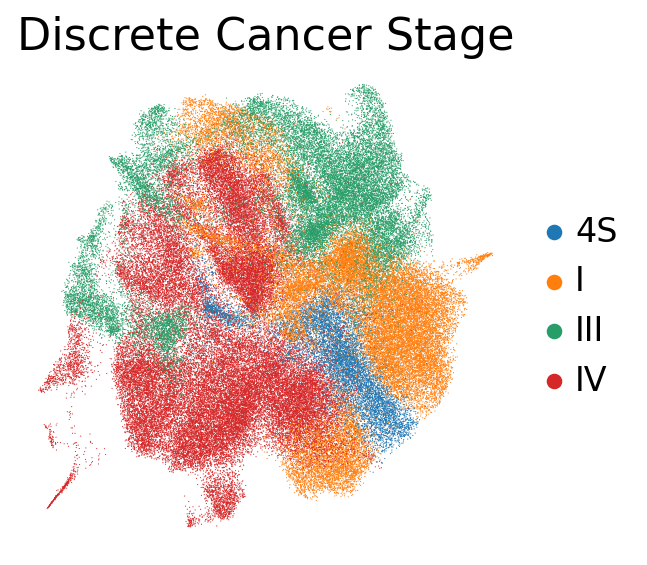

In [12]:
sc.pl.umap(adata, color='discrete_cancer_stage', frameon=False, legend_fontsize=15, legend_fontoutline=1, title="Discrete Cancer Stage", save="_NE_discrete_cancer_stage_legend.svg")

In [18]:
samples = adata.obs.sample_ID.cat.categories
samples

Index(['T27', 'T34', 'T40', 'T44', 'T69', 'T71', 'T75', 'T92', 'T162', 'T175',
       'T188', 'T200', 'T214', 'T230'],
      dtype='object')

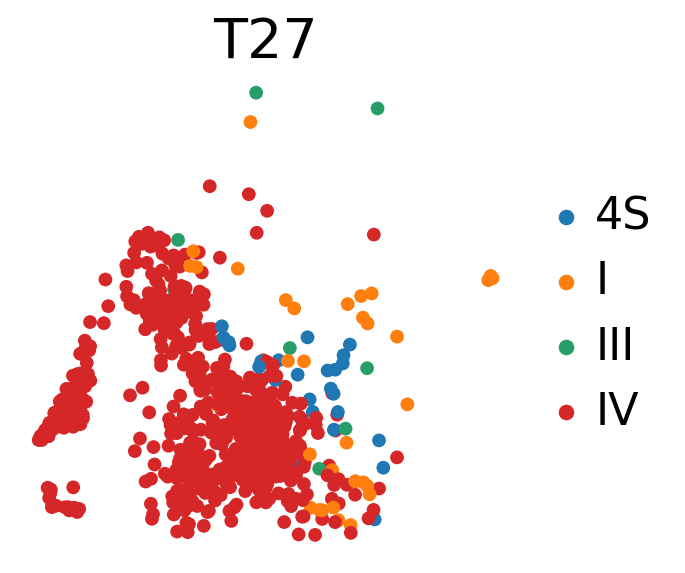

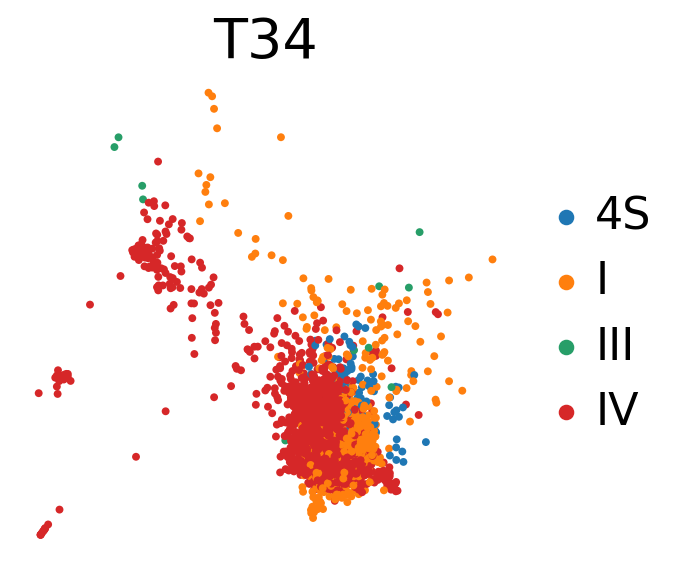

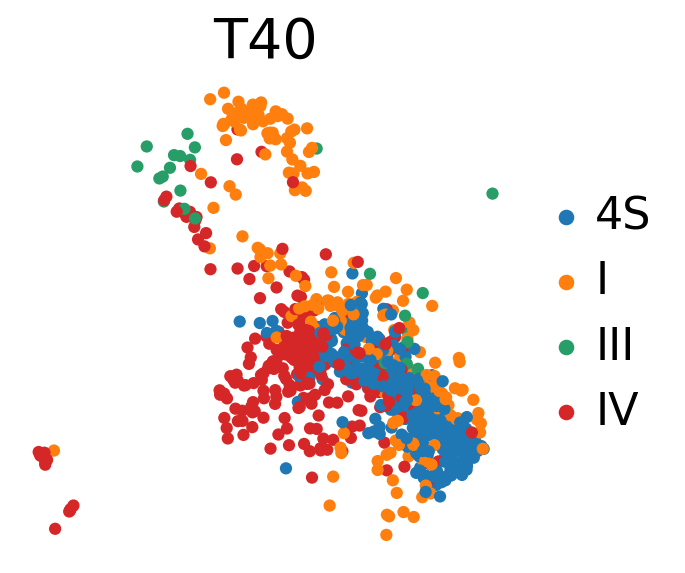

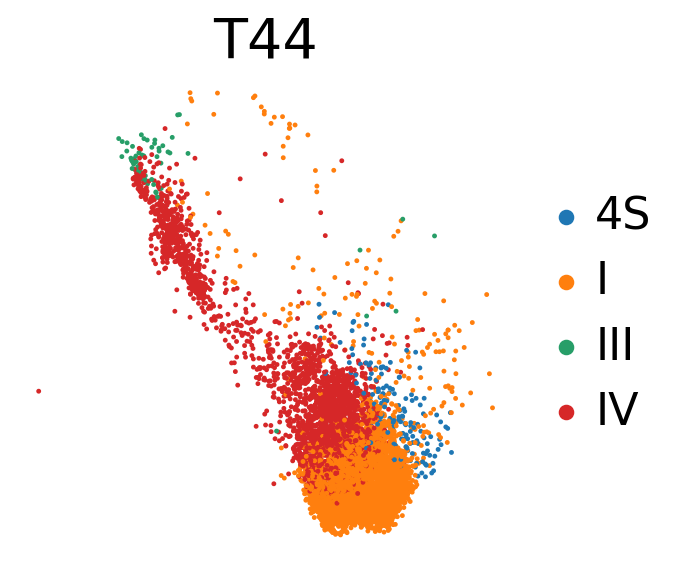

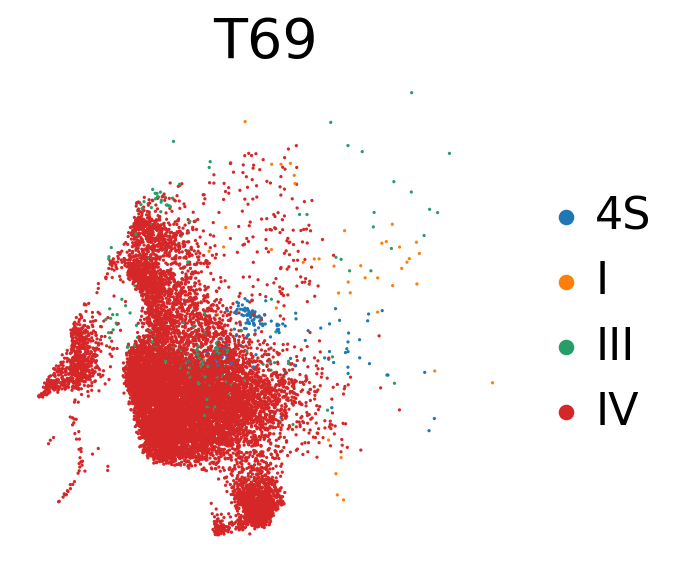

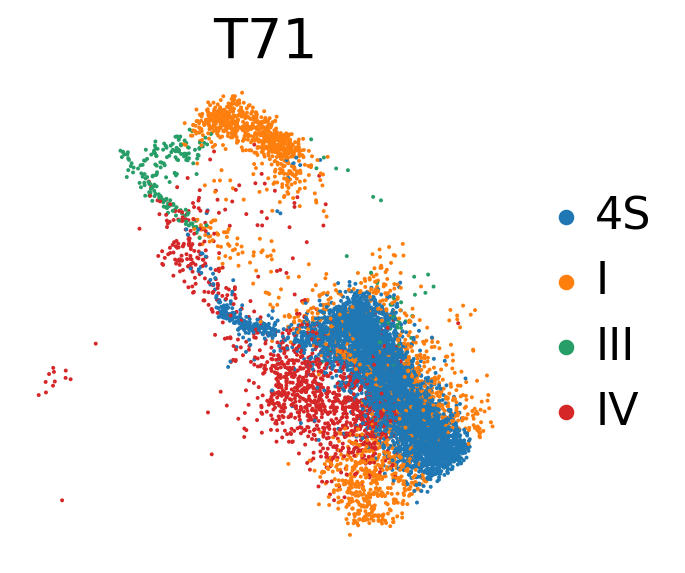

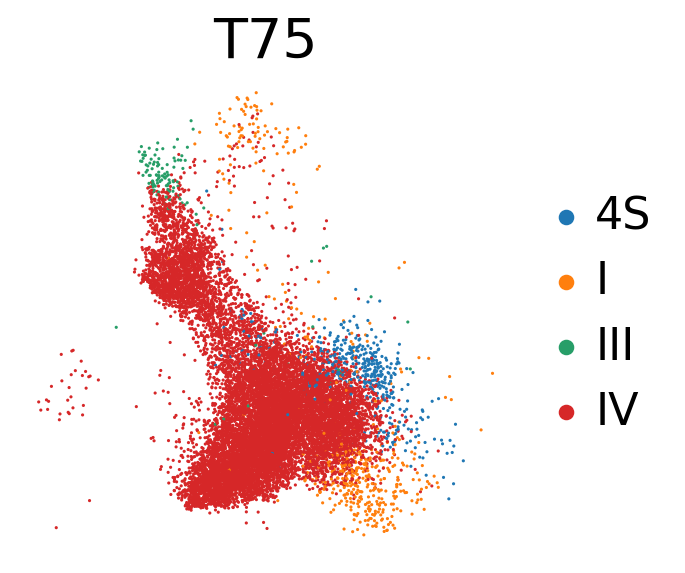

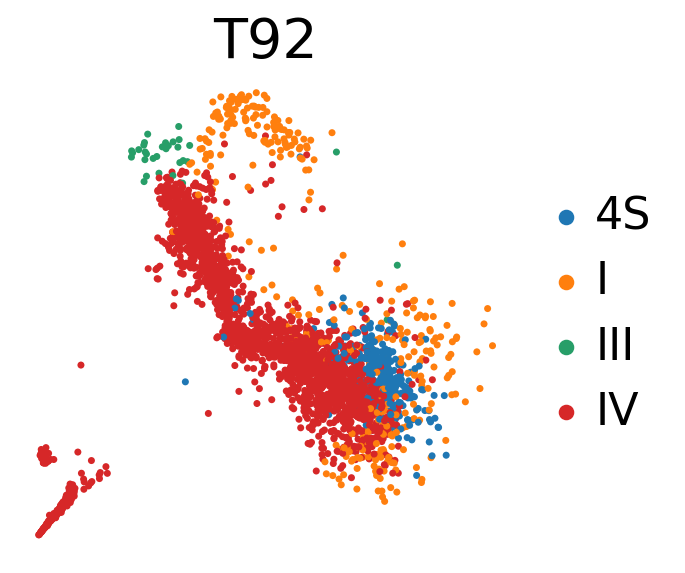

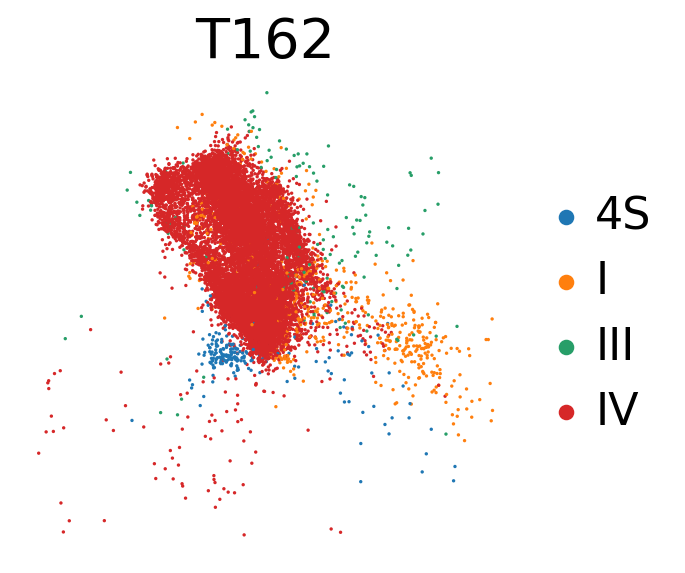

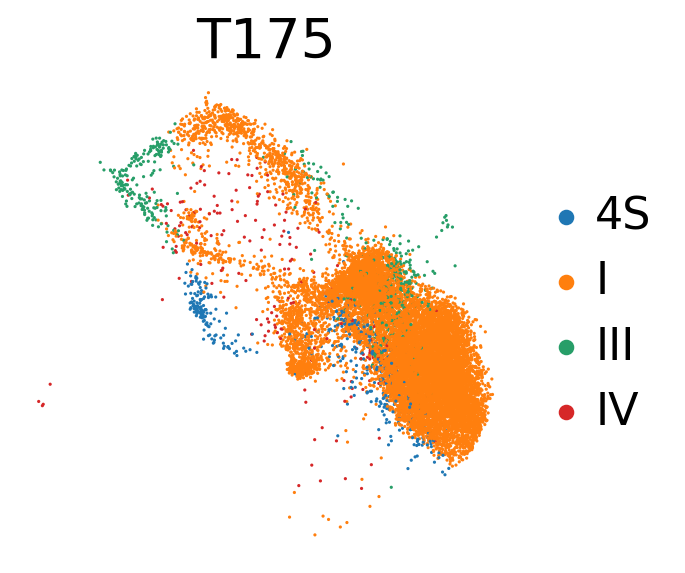

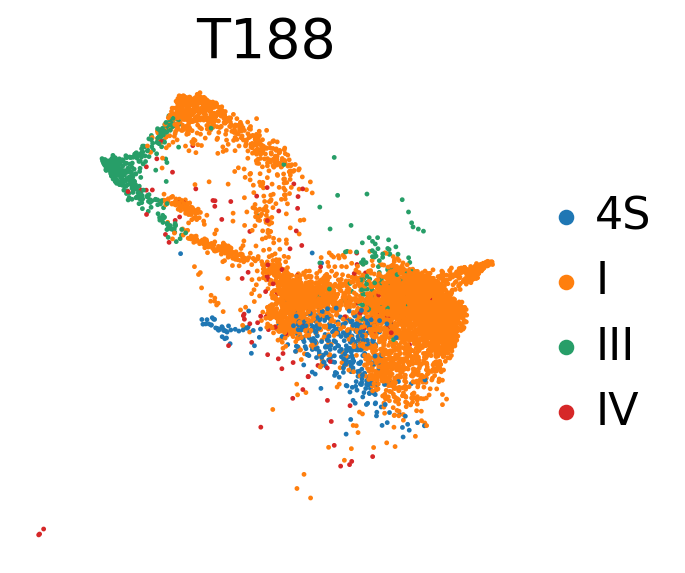

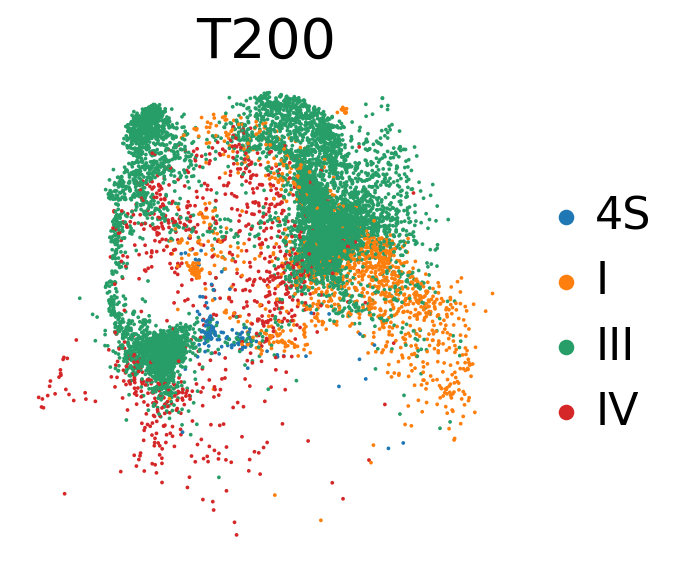

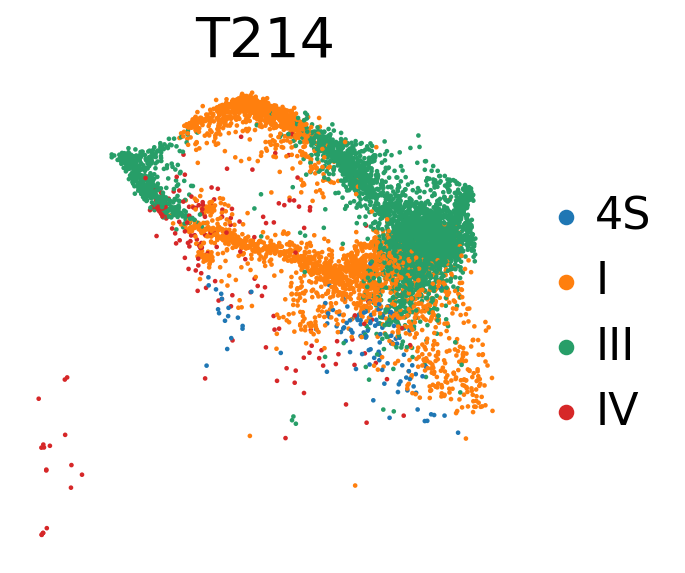

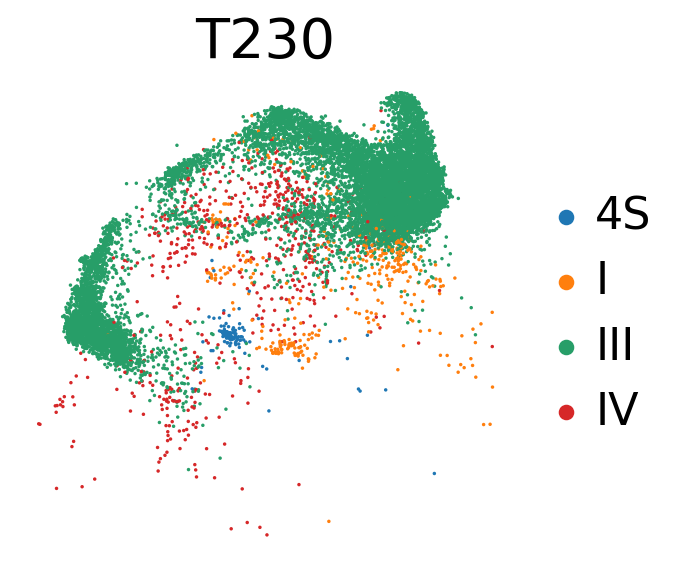

In [19]:
for i in samples:
    sc.pl.umap(adata[adata.obs.sample_ID==i], color='discrete_cancer_stage', frameon=False, legend_fontsize=20, legend_fontoutline=1, title=i, save=f"_{i}.svg")

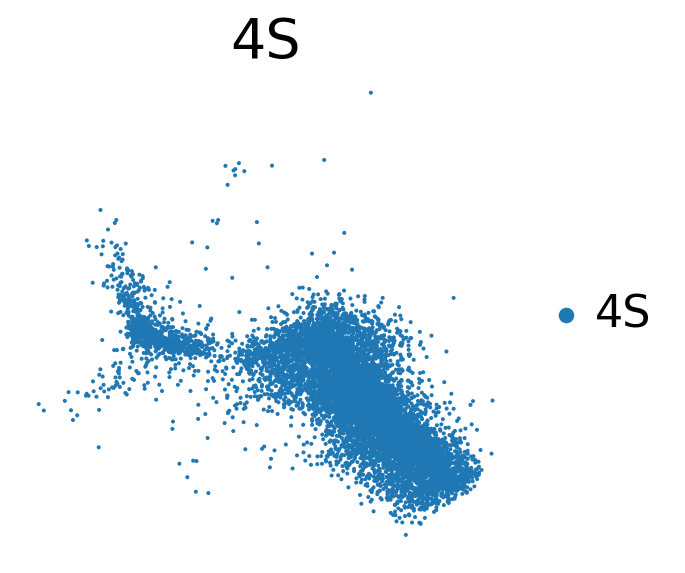

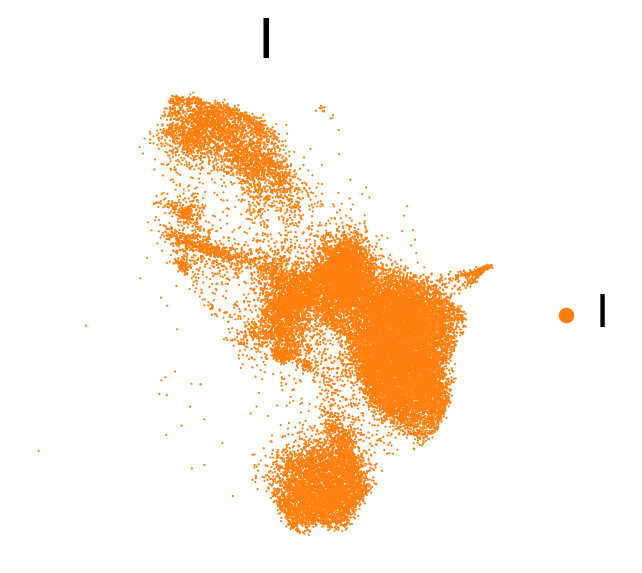

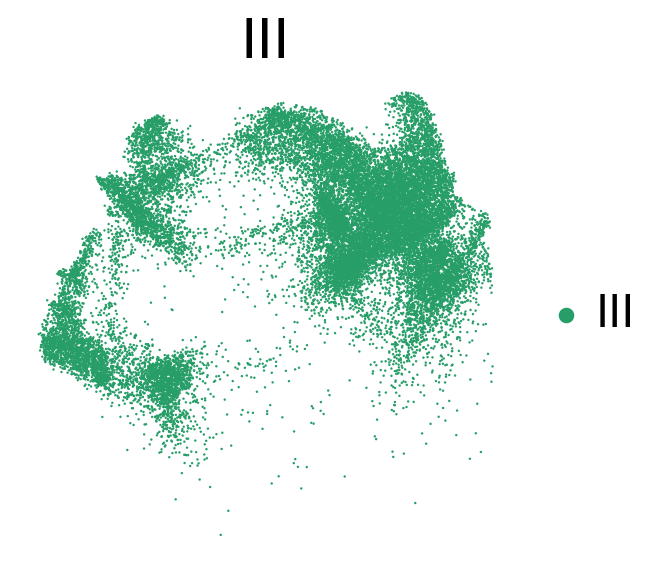

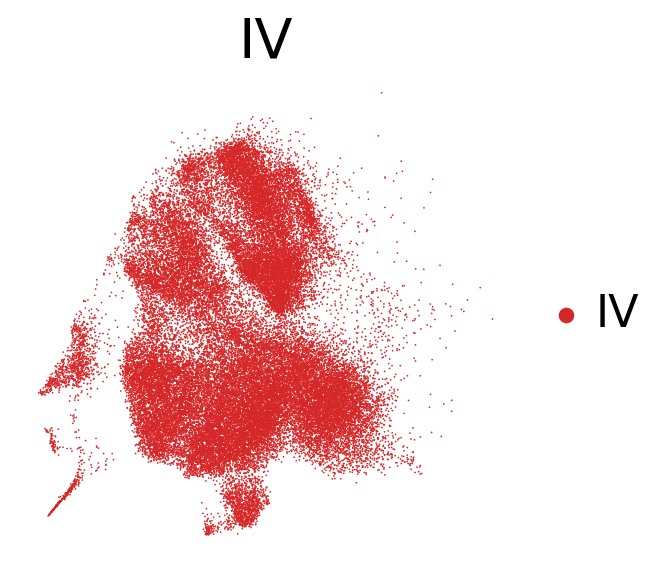

In [20]:
for i in ['4S', 'I', 'III', 'IV']:
    sc.pl.umap(adata[adata.obs.discrete_cancer_stage==i], color='discrete_cancer_stage', frameon=False, legend_fontsize=20, legend_fontoutline=1, title=i, save=f"_{i}.svg")

In [21]:
# Extract the relevant columns from the AnnData object
sample_stage_df = pd.DataFrame({
    'sample_ID': adata.obs['sample_ID'],
    'discrete_cancer_stage': adata.obs['discrete_cancer_stage']
})

# Group by 'sample_ID' and 'discrete_cancer_stage', then count the occurrences
stage_counts = sample_stage_df.groupby(['sample_ID', 'discrete_cancer_stage']).size().unstack(fill_value=0)

# Display the resulting table
print(stage_counts)

discrete_cancer_stage    4S      I    III     IV
sample_ID                                       
T27                      26     33      8    717
T34                      92    558     11   1729
T40                     462    209     27    287
T44                     166   3730     60   2342
T69                     153     47    249  13601
T71                    6024   1986    229   1228
T75                     465    520    122  13887
T92                     307    362     32   2308
T162                    219    557    159  12122
T175                    444  13364    567    208
T188                    373   5505    451    114
T200                    131   1248   8226    866
T214                    131   2557   4050    179
T230                    118    425  11194    589


In [22]:
# Extract the relevant columns from the AnnData object
sample_stage_df = pd.DataFrame({
    'sample_ID': adata.obs['sample_ID'],
    'discrete_cancer_stage': adata.obs['discrete_cancer_stage']
})

# Group by 'sample_ID' and 'discrete_cancer_stage', then count the occurrences
stage_counts = sample_stage_df.groupby(['sample_ID', 'discrete_cancer_stage']).size().unstack(fill_value=0)

# Calculate the total cell counts for each sample
total_counts = stage_counts.sum(axis=1)

# Calculate the percentage of cells in each stage for each sample
percentage_counts = stage_counts.div(total_counts, axis=0) * 100

# Combine total counts and percentage data into one table
output_table = stage_counts.copy()
output_table['Total Cells'] = total_counts
percentage_columns = {col: f"{col} (%)" for col in percentage_counts.columns}
percentage_counts.rename(columns=percentage_columns, inplace=True)
output_table = output_table.join(percentage_counts)

# Display the resulting table
output_table

discrete_cancer_stage,4S,I,III,IV,Total Cells,4S (%),I (%),III (%),IV (%)
sample_ID,,,,,,,,,
T27,26,33,8,717,784,3.316327,4.209184,1.020408,91.454082
T34,92,558,11,1729,2390,3.849372,23.347280,0.460251,72.343096
T40,462,209,27,287,985,46.903553,21.218274,2.741117,29.137056
T44,166,3730,60,2342,6298,2.635757,59.225151,0.952683,37.186408
T69,153,47,249,13601,14050,1.088968,0.334520,1.772242,96.804270
T71,6024,1986,229,1228,9467,63.631562,20.978135,2.418929,12.971374
T75,465,520,122,13887,14994,3.101240,3.468054,0.813659,92.617047
T92,307,362,32,2308,3009,10.202725,12.030575,1.063476,76.703224
T162,219,557,159,12122,13057,1.677261,4.265911,1.217738,92.839090


In [23]:
adata.write("discrete_cancer_stages_annotated.h5ad")